# Claim-Frequency Model Validation

This notebook reviews the exposure-adjusted claim-frequency models.

The analysis compares:

- a constant portfolio-frequency baseline;
- regularized Poisson regression;
- histogram gradient boosting with Poisson loss.

The models predict claims per exposure-year. Expected policy claim
counts are obtained by multiplying predicted frequency by exposure.

The preferred model was selected using validation Poisson deviance.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.6f}",
)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "modeling"
    / "claim_frequency"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "modeling"
    / "claim_frequency"
)

SPLIT_PATH = (
    REPORT_DIR
    / "split_summary.csv"
)

VALIDATION_PATH = (
    REPORT_DIR
    / "validation_frequency_model_comparison.csv"
)

TEST_PATH = (
    REPORT_DIR
    / "test_frequency_model_comparison.csv"
)

CALIBRATION_PATH = (
    REPORT_DIR
    / "frequency_calibration_deciles.csv"
)

SEGMENT_PATH = (
    REPORT_DIR
    / "segment_frequency_calibration.csv"
)

COEFFICIENT_PATH = (
    REPORT_DIR
    / "poisson_coefficients.csv"
)

paths = [
    SPLIT_PATH,
    VALIDATION_PATH,
    TEST_PATH,
    CALIBRATION_PATH,
    SEGMENT_PATH,
    COEFFICIENT_PATH,
]

for path in paths:
    print(
        f"{path.name}: {path.exists()}"
    )

split_summary.csv: True
validation_frequency_model_comparison.csv: True
test_frequency_model_comparison.csv: True
frequency_calibration_deciles.csv: True
segment_frequency_calibration.csv: True
poisson_coefficients.csv: True


In [2]:
split_summary = pd.read_csv(
    SPLIT_PATH
)

validation_results = pd.read_csv(
    VALIDATION_PATH
)

test_results = pd.read_csv(
    TEST_PATH
)

calibration = pd.read_csv(
    CALIBRATION_PATH
)

segment_calibration = pd.read_csv(
    SEGMENT_PATH
)

coefficients = pd.read_csv(
    COEFFICIENT_PATH
)

print("Data splits:")
display(split_summary)

print("Validation comparison:")
display(validation_results)

print("Test comparison:")
display(test_results)

Data splits:


,Sample,Policies,Exposure,Claims,ZeroClaimPolicies,OneClaimPolicies,MultipleClaimPolicies,ObservedFrequency,ClaimsPer100ExposureYears
0,Training,406807,"215,189.215175",21669,386371,19306,1130,0.100697,10.069743
1,Validation,135603,"71,713.998330",7224,128791,6436,376,0.100733,10.073347
2,Test,135603,"71,596.231958",7209,128791,6436,376,0.100690,10.068966


Validation comparison:


,Model,Sample,ExposureWeightedPoissonDeviance,CountMeanPoissonDeviance,D2Poisson,WeightedFrequencyMAE,CountMAE,CountRMSE,ObservedClaims,PredictedClaims,PredictedToObservedClaimsRatio,ObservedFrequency,PredictedFrequency,FrequencyDifference,PearsonDispersionDiagnostic
0,Constant frequency baseline,Validation,0.625622,0.330862,-0.000000,0.189090,0.100001,0.241463,"7,224.000000","7,221.415016",0.999642,0.100733,0.100697,-0.000036,2.975052
1,Poisson regression,Validation,0.607050,0.321040,0.029686,0.187358,0.099085,0.240126,"7,224.000000","7,254.922123",1.004280,0.100733,0.101165,0.000431,2.752857
2,Histogram gradient boosting,Validation,0.576230,0.304741,0.078949,0.182414,0.096470,0.238579,"7,224.000000","7,205.700071",0.997467,0.100733,0.100478,-0.000255,2.257725


Test comparison:


,Model,Sample,ExposureWeightedPoissonDeviance,CountMeanPoissonDeviance,D2Poisson,WeightedFrequencyMAE,CountMAE,CountRMSE,ObservedClaims,PredictedClaims,PredictedToObservedClaimsRatio,ObservedFrequency,PredictedFrequency,FrequencyDifference,PearsonDispersionDiagnostic
0,Constant frequency baseline,Test,0.622283,0.328555,-0.000000,0.189029,0.099804,0.238398,"7,209.000000","7,209.556246",1.000077,0.100690,0.100697,0.000008,2.630600
1,Poisson regression,Test,0.601274,0.317463,0.033760,0.187039,0.098753,0.236929,"7,209.000000","7,235.900770",1.003732,0.100690,0.101065,0.000376,2.351786
2,Histogram gradient boosting,Test,0.566760,0.299240,0.089224,0.181664,0.095916,0.234158,"7,209.000000","7,224.462907",1.002145,0.100690,0.100906,0.000216,2.009191


In [3]:
comparison_columns = [
    "Model",
    "ExposureWeightedPoissonDeviance",
    "CountMeanPoissonDeviance",
    "D2Poisson",
    "CountMAE",
    "CountRMSE",
    "ObservedClaims",
    "PredictedClaims",
    "PredictedToObservedClaimsRatio",
    "ObservedFrequency",
    "PredictedFrequency",
    "PearsonDispersionDiagnostic",
]

display(
    test_results[
        comparison_columns
    ].sort_values(
        "ExposureWeightedPoissonDeviance"
    )
)

,Model,ExposureWeightedPoissonDeviance,CountMeanPoissonDeviance,D2Poisson,CountMAE,CountRMSE,ObservedClaims,PredictedClaims,PredictedToObservedClaimsRatio,ObservedFrequency,PredictedFrequency,PearsonDispersionDiagnostic
2,Histogram gradient boosting,0.566760,0.299240,0.089224,0.095916,0.234158,"7,209.000000","7,224.462907",1.002145,0.100690,0.100906,2.009191
1,Poisson regression,0.601274,0.317463,0.033760,0.098753,0.236929,"7,209.000000","7,235.900770",1.003732,0.100690,0.101065,2.351786
0,Constant frequency baseline,0.622283,0.328555,-0.000000,0.099804,0.238398,"7,209.000000","7,209.556246",1.000077,0.100690,0.100697,2.630600


In [4]:
trained_validation_results = (
    validation_results.loc[
        ~validation_results[
            "Model"
        ].eq(
            "Constant frequency baseline"
        )
    ]
)

selected_model = (
    trained_validation_results.sort_values(
        [
            "ExposureWeightedPoissonDeviance",
            "D2Poisson",
        ],
        ascending=[True, False],
    )
    .iloc[0]["Model"]
)

selected_test = test_results.loc[
    test_results["Model"].eq(
        selected_model
    )
].iloc[0]

print(
    "Validation-selected frequency model:",
    selected_model,
)

display(
    selected_test.to_frame(
        name="Value"
    )
)

Validation-selected frequency model: Histogram gradient boosting


,Value
Model,Histogram gradient boosting
Sample,Test
ExposureWeightedPoissonDeviance,0.566760
CountMeanPoissonDeviance,0.299240
D2Poisson,0.089224
WeightedFrequencyMAE,0.181664
CountMAE,0.095916
CountRMSE,0.234158
ObservedClaims,"7,209.000000"
PredictedClaims,"7,224.462907"


In [5]:
print(
    "Observed test claims:",
    f"{selected_test['ObservedClaims']:,.0f}",
)

print(
    "Predicted test claims:",
    f"{selected_test['PredictedClaims']:,.2f}",
)

print(
    "Predicted-to-observed ratio:",
    f"{selected_test['PredictedToObservedClaimsRatio']:.4f}",
)

print(
    "Observed portfolio frequency:",
    f"{selected_test['ObservedFrequency']:.6f}",
)

print(
    "Predicted portfolio frequency:",
    f"{selected_test['PredictedFrequency']:.6f}",
)

print(
    "Pearson dispersion diagnostic:",
    f"{selected_test['PearsonDispersionDiagnostic']:.4f}",
)

Observed test claims: 7,209
Predicted test claims: 7,224.46
Predicted-to-observed ratio: 1.0021
Observed portfolio frequency: 0.100690
Predicted portfolio frequency: 0.100906
Pearson dispersion diagnostic: 2.0092


In [6]:
display(
    calibration[
        [
            "RiskDecile",
            "Policies",
            "Exposure",
            "ObservedClaims",
            "PredictedClaims",
            "ObservedFrequency",
            "PredictedFrequency",
            "ObservedToExpectedRatio",
        ]
    ]
)

,RiskDecile,Policies,Exposure,ObservedClaims,PredictedClaims,ObservedFrequency,PredictedFrequency,ObservedToExpectedRatio
0,1,13561,"8,415.945941",326,335.040791,0.038736,0.039810,0.973016
1,2,13560,"8,032.998547",442,425.295687,0.055023,0.052944,1.039277
2,3,13560,"7,587.327404",445,468.759722,0.058650,0.061782,0.949314
3,4,13560,"7,358.463927",495,517.364799,0.067269,0.070309,0.956772
4,5,13561,"7,698.003501",618,601.950738,0.080281,0.078196,1.026662
5,6,13560,"8,046.739254",703,688.179598,0.087365,0.085523,1.021536
6,7,13560,"7,405.959553",667,708.636277,0.090063,0.095685,0.941245
7,8,13560,"6,172.918409",756,708.142601,0.122470,0.114718,1.067582
8,9,13560,"5,925.658270",843,928.411689,0.142263,0.156677,0.908002
9,10,13561,"4,952.217151",1914,"1,842.681005",0.386494,0.372092,1.038704


In [7]:
lowest_decile = (
    calibration.sort_values(
        "RiskDecile"
    )
    .iloc[0]
)

highest_decile = (
    calibration.sort_values(
        "RiskDecile"
    )
    .iloc[-1]
)

frequency_separation = (
    highest_decile[
        "ObservedFrequency"
    ]
    / lowest_decile[
        "ObservedFrequency"
    ]
)

print(
    "Lowest-decile observed frequency:",
    f"{lowest_decile['ObservedFrequency']:.6f}",
)

print(
    "Highest-decile observed frequency:",
    f"{highest_decile['ObservedFrequency']:.6f}",
)

print(
    "Highest-to-lowest observed frequency ratio:",
    f"{frequency_separation:.2f}",
)

Lowest-decile observed frequency: 0.038736
Highest-decile observed frequency: 0.386494
Highest-to-lowest observed frequency ratio: 9.98


In [8]:
for segment_type in [
    "Area",
    "VehGas",
    "DrivAgeBand",
    "BonusMalusBand",
]:
    print(
        f"Calibration by {segment_type}:"
    )

    display(
        segment_calibration.loc[
            segment_calibration[
                "SegmentType"
            ].eq(segment_type)
        ][
            [
                "Segment",
                "Policies",
                "Exposure",
                "ObservedClaims",
                "PredictedClaims",
                "ObservedFrequency",
                "PredictedFrequency",
                "ObservedToExpectedRatio",
                "EligibleForComparison",
            ]
        ]
    )

Calibration by Area:


,Segment,Policies,Exposure,ObservedClaims,PredictedClaims,ObservedFrequency,PredictedFrequency,ObservedToExpectedRatio,EligibleForComparison
0,A,20772,"12,382.159233",993,994.415713,0.080196,0.080310,0.998576,True
1,B,15200,"8,652.804723",783,739.934247,0.090491,0.085514,1.058202,True
2,C,38320,"20,886.274056",2045,"1,965.545337",0.097911,0.094107,1.040424,True
3,D,30317,"15,406.002969",1609,"1,728.380825",0.104440,0.112189,0.930929,True
4,E,27355,"12,630.574521",1533,"1,568.044015",0.121372,0.124147,0.977651,True
5,F,3639,"1,638.416456",246,228.142770,0.150145,0.139246,1.078272,True


Calibration by VehGas:


,Segment,Policies,Exposure,ObservedClaims,PredictedClaims,ObservedFrequency,PredictedFrequency,ObservedToExpectedRatio,EligibleForComparison
6,'Diesel',66553,"34,238.897051",3293,"3,330.502355",0.096177,0.097272,0.988740,True
7,'Regular',69050,"37,357.334908",3916,"3,893.960551",0.104825,0.104236,1.005660,True


Calibration by DrivAgeBand:


,Segment,Policies,Exposure,ObservedClaims,PredictedClaims,ObservedFrequency,PredictedFrequency,ObservedToExpectedRatio,EligibleForComparison
8,Under 21,1335,503.709270,135,121.268295,0.268012,0.240751,1.113234,True
9,21-24,4637,"1,937.745045",343,333.243224,0.177010,0.171975,1.029278,True
10,25-29,11799,"5,170.355553",603,586.023800,0.116626,0.113343,1.028968,True
11,30-39,33695,"16,403.100099",1443,"1,475.895888",0.087971,0.089977,0.977711,True
12,40-49,33023,"17,519.691143",1772,"1,810.566223",0.101143,0.103345,0.978699,True
13,50-59,28682,"16,050.575143",1565,"1,593.609180",0.097504,0.099287,0.982048,True
14,60-69,13556,"8,003.466612",739,744.684742,0.092335,0.093045,0.992366,True
15,70-79,7335,"4,855.283389",486,458.431594,0.100097,0.094419,1.060136,True
16,80+,1541,"1,152.305703",123,100.739962,0.106743,0.087425,1.220965,True


Calibration by BonusMalusBand:


,Segment,Policies,Exposure,ObservedClaims,PredictedClaims,ObservedFrequency,PredictedFrequency,ObservedToExpectedRatio,EligibleForComparison
17,Below 60,92268,"52,963.507891",4334,"4,356.811550",0.081830,0.082261,0.994764,True
18,60-69,14566,"6,788.300664",844,901.555070,0.124332,0.132810,0.936160,True
19,70-79,8940,"3,901.865658",550,487.290510,0.140958,0.124887,1.128690,True
20,80-89,7396,"3,069.240577",411,425.446577,0.133909,0.138616,0.966044,True
21,90-99,6911,"2,889.833332",450,434.034881,0.155718,0.150194,1.036783,True
22,100-109,4338,"1,445.192510",406,410.920584,0.280931,0.284336,0.988025,True
23,110-129,1030,465.453997,175,177.055795,0.375977,0.380394,0.988389,False
24,130-149,112,54.499133,27,21.748593,0.495421,0.399063,1.241460,False
25,150+,42,18.338197,12,9.599347,0.654372,0.523462,1.250085,False


In [9]:
positive_coefficients = (
    coefficients.loc[
        coefficients["Coefficient"] > 0
    ]
    .sort_values(
        "Coefficient",
        ascending=False,
    )
    .head(15)
)

negative_coefficients = (
    coefficients.loc[
        coefficients["Coefficient"] < 0
    ]
    .sort_values(
        "Coefficient",
        ascending=True,
    )
    .head(15)
)

print("Strongest positive Poisson coefficients:")
display(
    positive_coefficients[
        [
            "Feature",
            "Coefficient",
            "RateRatio",
        ]
    ]
)

print("Strongest negative Poisson coefficients:")
display(
    negative_coefficients[
        [
            "Feature",
            "Coefficient",
            "RateRatio",
        ]
    ]
)

Strongest positive Poisson coefficients:


,Feature,Coefficient,RateRatio
0,numeric__BonusMalus,0.350864,1.420295
3,categorical__Region_R21,0.226513,1.254219
5,categorical__VehBrand_B12,0.158007,1.171174
6,categorical__Region_R74,0.145907,1.157088
8,categorical__Area_D,0.109670,1.115910
10,categorical__Area_E,0.099927,1.105091
11,categorical__Region_R53,0.099572,1.104698
12,numeric__DrivAge,0.088544,1.092582
14,categorical__VehBrand_B5,0.079179,1.082398
15,categorical__Region_R24,0.067963,1.070326


Strongest negative Poisson coefficients:


,Feature,Coefficient,RateRatio
1,categorical__Region_R83,-0.244162,0.783361
2,categorical__Region_R41,-0.231233,0.793554
4,numeric__VehAge,-0.213572,0.807694
7,categorical__VehBrand_B14,-0.122285,0.884896
9,categorical__Region_R73,-0.106092,0.899342
13,categorical__Region_R31,-0.086839,0.916824
16,categorical__Region_R72,-0.066947,0.935245
19,categorical__Region_R23,-0.063164,0.938790
22,categorical__Region_R43,-0.058090,0.943565
23,categorical__Region_R26,-0.053721,0.947697


test_poisson_deviance_comparison.png


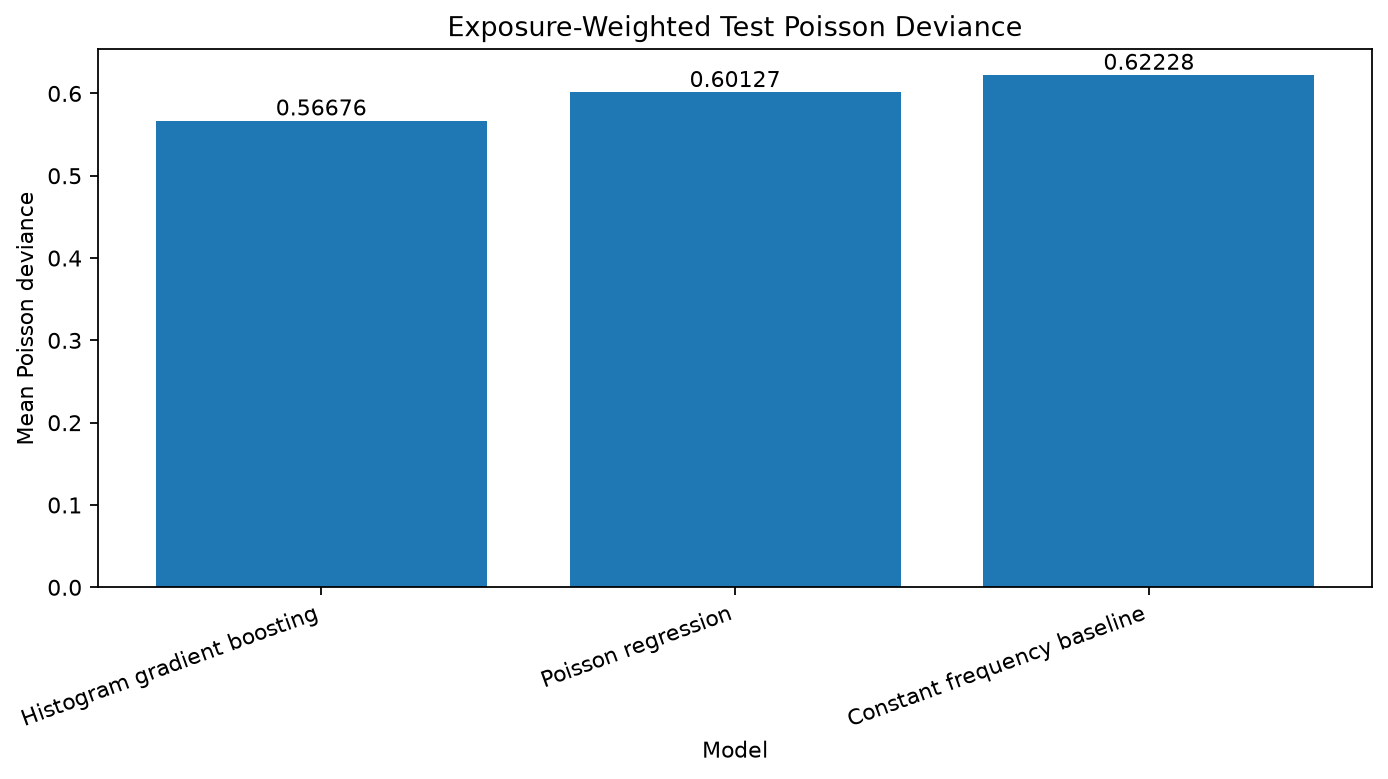

frequency_calibration_deciles.png


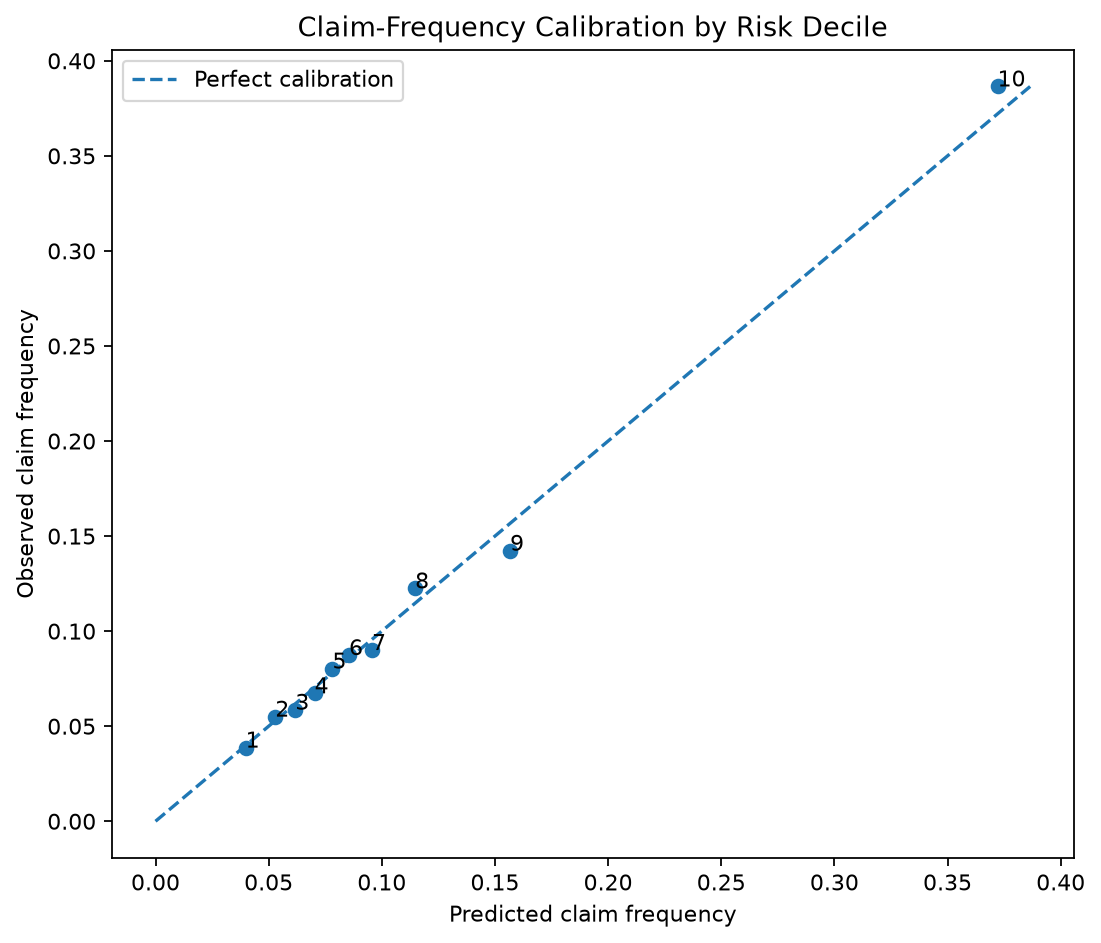

observed_predicted_frequency_by_decile.png


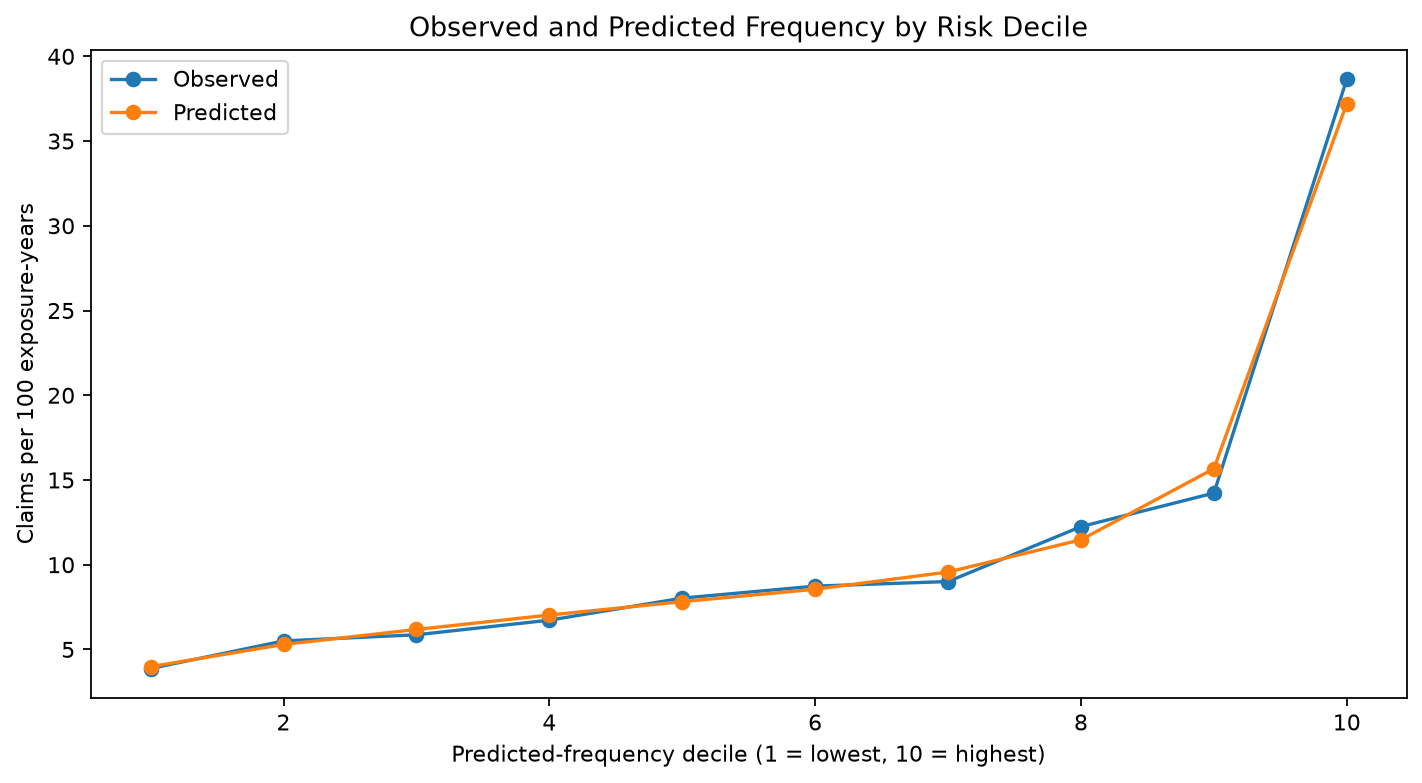

bonus_malus_frequency_calibration.png


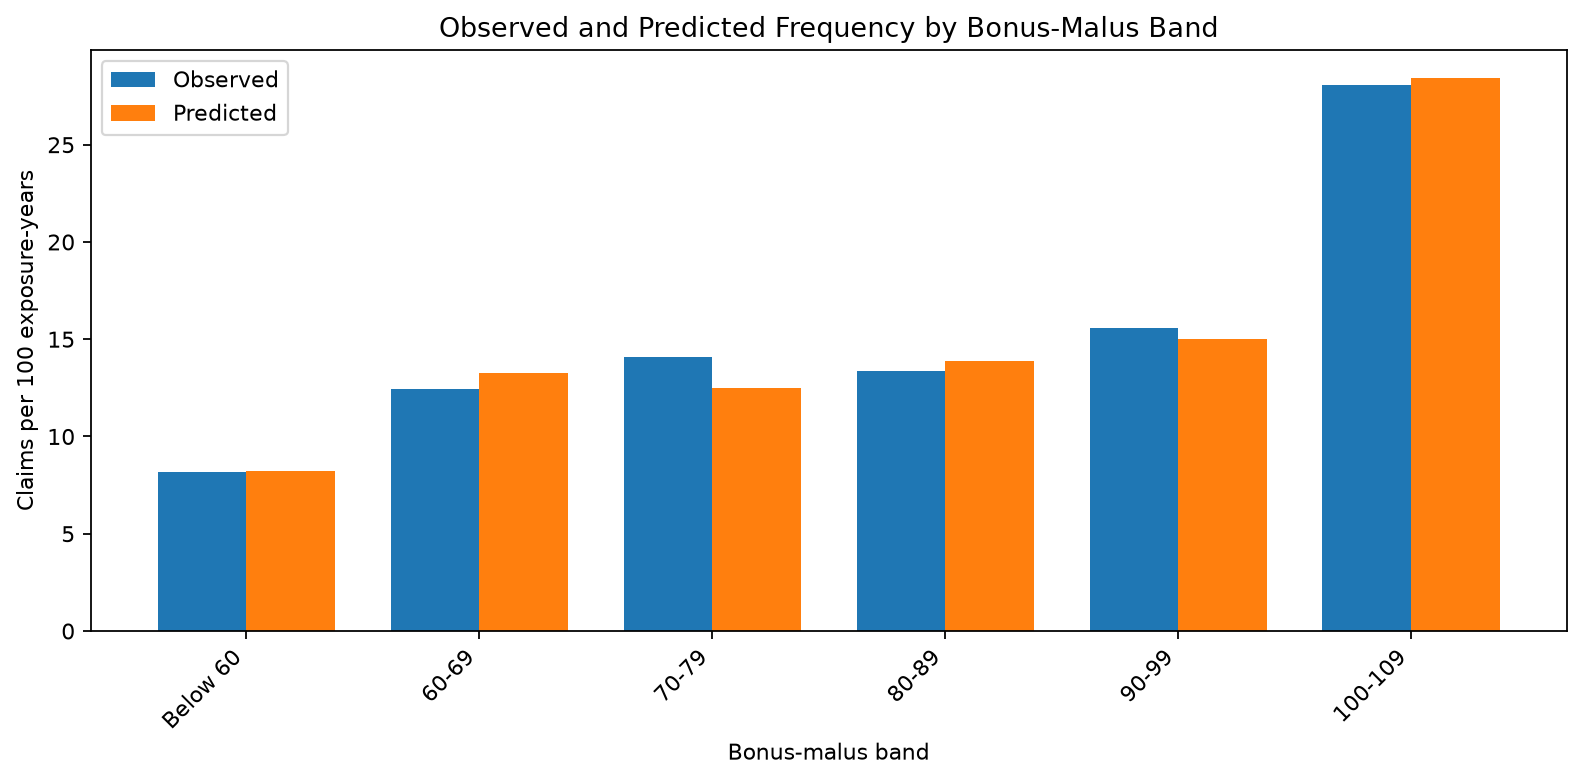

In [10]:
figure_files = [
    "test_poisson_deviance_comparison.png",
    "frequency_calibration_deciles.png",
    "observed_predicted_frequency_by_decile.png",
    "bonus_malus_frequency_calibration.png",
]

for filename in figure_files:
    print(filename)

    display(
        Image(
            filename=str(
                FIGURES_DIR
                / filename
            )
        )
    )

In [11]:
trained_test_results = test_results.loc[
    ~test_results["Model"].eq(
        "Constant frequency baseline"
    )
]

checks = pd.DataFrame(
    {
        "Validation": [
            "Three models were evaluated",
            "Selected model came from validation",
            "All predicted claim totals are positive",
            "All Poisson deviances are finite",
            "Calibration contains ten deciles",
            "Risk decile ten has higher observed frequency than decile one",
            "Segment calibration is non-empty",
            "Poisson coefficient table is non-empty",
        ],
        "Passed": [
            len(test_results) == 3,
            selected_model
            in trained_validation_results[
                "Model"
            ].tolist(),
            test_results[
                "PredictedClaims"
            ].gt(0).all(),
            test_results[
                "ExposureWeightedPoissonDeviance"
            ].notna().all(),
            calibration[
                "RiskDecile"
            ].nunique() == 10,
            highest_decile[
                "ObservedFrequency"
            ]
            > lowest_decile[
                "ObservedFrequency"
            ],
            len(segment_calibration) > 0,
            len(coefficients) > 0,
        ],
    }
)

display(checks)

print(
    "All validation checks passed:",
    checks["Passed"].all(),
)

,Validation,Passed
0,Three models were evaluated,True
1,Selected model came from validation,True
2,All predicted claim totals are positive,True
3,All Poisson deviances are finite,True
4,Calibration contains ten deciles,True
5,Risk decile ten has higher observed frequency ...,True
6,Segment calibration is non-empty,True
7,Poisson coefficient table is non-empty,True


All validation checks passed: True
